# Storm Trajectory Sensitivity on the Bellinge 1D/2D Model

Two storms drop exactly the same amount of water on the same city. The first sweeps in from the west and tracks
east. The second climbs up from the south. Do they flood the same streets, to the same depth?

Standard practice mostly assumes they do. A design storm is a rainfall depth and a duration applied everywhere at
once, so it has no direction to speak of. This notebook tests that assumption directly. We take one real convective
storm recorded over the Bellinge catchment in Odense, Denmark, make nine copies of it traveling along nine different
compass bearings, force every copy to deliver an identical total volume of water, and run each through a coupled
pipe and surface model of the real drainage network. Whatever differences appear at the end can only have come from
the direction of travel, because that is the only thing we allowed to vary.

## What a reentrant engine has to do with any of this

Picture a chess grandmaster playing a simultaneous exhibition. Twenty boards are set up in a row, each holding its
own position, and the grandmaster walks down the line playing one move per board. Every game advances together.

Many simulation engines work the opposite way. They keep the state of the running simulation in global memory, so
there is only ever one board in the room. You have to finish a game before you can set up the next one.

`openswmm.engine` is reentrant, which means each `Solver` object carries its entire simulation inside itself and
shares nothing outside. That gives us the row of boards. Most of this notebook does not need it, since running an
ensemble one simulation at a time works perfectly well. Part 7 is where it earns its place, when six storms are
opened at once and stepped forward together so that every frame of an animation shows six possible futures of the
same catchment at the same instant in simulated time.

## How the notebook is laid out

We start with the drainage network itself, then pull a real storm out of a radar archive. We measure how fast and in
which direction that storm was moving, which lets us rebuild it as a portable object we can send across the
catchment on any heading we choose. Then we drape a triangular surface over the terrain and connect it to the pipes,
test a single run to confirm the physics is behaving, and finally launch the full comparison.


In [1]:
import os
# Must be set before `openswmm.engine` is imported anywhere in this process:
# the engine links Homebrew's libomp while the conda numpy/scipy stack loads
# its own copy, and macOS aborts on the duplicate OpenMP runtime otherwise.
# This is the standard, documented workaround for that conda + Homebrew
# conflict -- not a numerical hazard.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "2")

import sys
import importlib
from pathlib import Path
# repo root = parent of notebooks/, so `swmm_storm` is importable
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

# Import order matters here: `openswmm.engine` must load before `rasterio`
# (pulled in transitively by `swmm_storm.mesh`) is imported anywhere in this
# process. Both bundle their own copies of shared native dependencies
# (GDAL's stack vs. openswmm's vcpkg-built libraries), and importing
# rasterio first causes a segfault the moment a SECOND `Solver` is opened
# while a first one is still open -- reproduced with a 2-line repro; a
# single Solver open/close at a time is unaffected either way, which is why
# this never surfaced in the ensemble runs earlier in the notebook.
import openswmm.engine  # noqa: F401 -- import-order guard, see above

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import the project's own modules, then force-reload them so that edits to
# swmm_storm/*.py take effect without restarting the kernel (helpful while
# developing locally; a no-op on first load in a fresh kernel).
from swmm_storm import config, inp_utils as iu, radar, advection as adv, mesh as mesh_mod, model, run, figures
for _m in (config, iu, radar, adv, mesh_mod, model, run, figures):
    importlib.reload(_m)

# Set to True to force every cached stage (radar cube, mesh, ensemble runs) to
# recompute from scratch. Leave False for a fast, cache-backed re-run.
FORCE_RERUN = False

# Fail early with a readable message if the Bellinge dataset is not in place.
# It is third-party data and is not shipped with this repository; see README.
config.require_data()

pd.set_option("display.width", 160)
plt.rcParams["figure.facecolor"] = "white"
print("openswmm.engine HAS_2D:", __import__("openswmm.engine", fromlist=["HAS_2D"]).HAS_2D)

openswmm.engine HAS_2D: True


## Part 1. The drainage network we are testing

Bellinge is a neighborhood in Odense, Denmark, and its sewer system is one of the few real networks published openly
enough to experiment with. The model contains 995 junctions, which you can picture as manholes, along with 16
storage structures such as detention basins, and 713 subcatchments, which are the parcels of land that shed
rainwater into each pipe.

The published version is driven by two rain gages covering the whole catchment. That is completely normal practice,
and it is also exactly the limitation we want to remove, because two gages cannot tell you which end of town got hit
first. Over the next few sections we replace them with 58 radar pixels and add a ground surface so that water has
somewhere to go when a pipe fills past capacity. The pipe network itself stays exactly as published.


1011 nodes (995 junctions, 16 storage)
713 subcatchments, 8036 polygon vertices
network extent (EPSG:25832): x [579840, 586713]  y [6132313, 6135537]
rim elevation range: 10.8 - 51.8 m


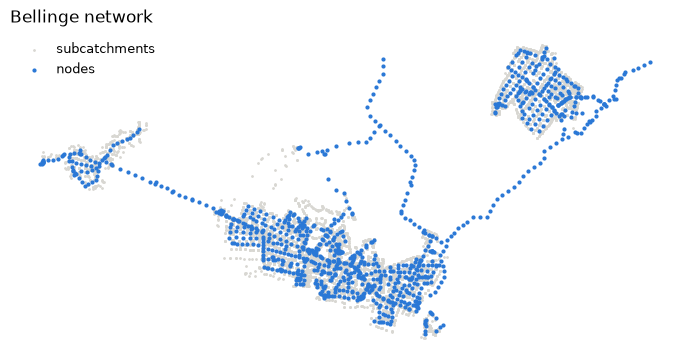

In [2]:
inp_text = open(config.INP_PATH, errors="ignore").read()
sections = iu.split_sections(inp_text)
nodes = iu.read_node_table(sections)
poly_xy = iu.read_polygon_vertices(sections)
outlets = iu.read_subcatchment_outlets(sections)

print(f"{len(nodes)} nodes ({(nodes.kind=='JUNCTIONS').sum()} junctions, {(nodes.kind=='STORAGE').sum()} storage)")
print(f"{len(outlets)} subcatchments, {len(poly_xy)} polygon vertices")
print(f"network extent (EPSG:25832): x [{nodes.x.min():.0f}, {nodes.x.max():.0f}]  "
      f"y [{nodes.y.min():.0f}, {nodes.y.max():.0f}]")
print(f"rim elevation range: {nodes.rim.min():.1f} - {nodes.rim.max():.1f} m")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(poly_xy[:, 0], poly_xy[:, 1], s=1, color="#d8d7d2", label="subcatchments")
ax.scatter(nodes.x, nodes.y, s=4, color="#2a78d6", label="nodes")
ax.set_aspect("equal"); ax.set_title("Bellinge network", loc="left")
ax.legend(frameon=False, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout()


## Part 2. Finding a real storm worth moving around

A rain gage is a microphone. It tells you loudness over time at a single spot. Weather radar is closer to a video
camera, recording the whole scene at once, and that difference is what makes this notebook possible at all. You
cannot move a storm you only measured at two points, because you never saw its shape.

The Bellinge archive holds X-band radar from 2012 through 2020 as 58 separate files, one per pixel, on a grid of
926 meter squares sampled every minute. Stacked together they form a rainfall movie.

Before trusting any of it, we rank the wettest days, and the top result turns out to be a warning rather than a
storm. One pixel reports roughly 2150 mm in a single day, about a hundred times a heavy Danish downpour and
comfortably beyond the world record. That is a sensor fault, and a quality check screens it out. Skipping this step
would mean modeling a catastrophe that never happened, and every flood number after it would be fiction.

The genuine record holder is 29 June 2012. Between 05:00 and 08:00 it delivered 20 to 43 mm across the catchment,
with peak intensities of 93 to 186 mm/hr. It is fast, compact and convective, which is the type of storm where
direction of travel should matter most. A slow, wide frontal system soaks everything fairly evenly, so its heading
changes little. A tight, intense cell behaves more like a moving spotlight, and where it points is the whole
question.


In [3]:
ranked = radar.rank_event_dates(pixel_id=895, n=8)
display(ranked.to_frame("total_mm"))


,total_mm
date,
2017-08-20,2150.284415
2012-06-29,42.736290
2015-07-25,40.376285
2014-08-17,36.889394
2014-10-19,36.109774
2015-08-31,35.969789
2013-05-22,33.623787
2014-12-12,33.555113


cube: (360, 7, 9) (time, row, col), 5 interpolated cells


,pixel_id,row,col,x,y,event_total_mm,event_peak_mm_hr
17,895,2,3,582244.0,6133773.0,36.255801,186.480894
41,925,5,4,583170.0,6136551.0,35.818095,109.518261
40,924,4,4,583170.0,6135625.0,34.364700,135.260714
32,916,2,4,583170.0,6133773.0,33.639488,152.517377
16,894,1,3,582244.0,6132847.0,33.270428,193.317882


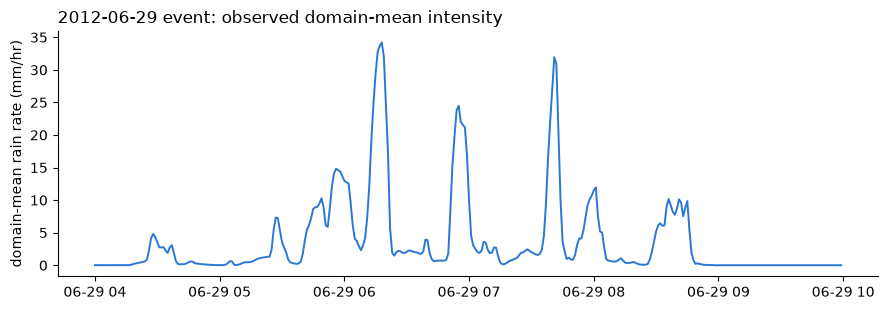

In [4]:
cube = radar.build_event_cube(force=FORCE_RERUN)
print(f"cube: {cube['R'].shape} (time, row, col), {cube['filled_mask'].sum()} interpolated cells")
display(cube["qc"].sort_values("event_total_mm", ascending=False).head())

domain_mean = radar.domain_mean_series(cube)
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(domain_mean.index, domain_mean.values, color="#2a78d6", linewidth=1.4)
ax.set_ylabel("domain-mean rain rate (mm/hr)"); ax.set_title(
    "2012-06-29 event: observed domain-mean intensity", loc="left")
for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.tight_layout()


## Part 3. Turning one storm into nine

Imagine a patterned rug being dragged across a floor. Stand still, watch one spot, and the pattern beneath you keeps
changing. The rug itself is not changing at all. It is simply moving. If you record everything that passes that one
spot, and you know how fast the rug is sliding and in which direction, you can reconstruct the whole pattern. Once
you hold the pattern, you can drag it across the floor any way you please.

That idea is Taylor's frozen field hypothesis, and it is how we get nine storms out of one. We track the center of
mass of the rainfall as it crosses the catchment, measure its velocity, then convert every radar reading from "what
fell at this place at this time" into "what fell at this position relative to the storm's own center." The result is
a portable map of the storm, which we call its footprint. Sending it back across the catchment on a new heading
becomes arithmetic.

Working this way rather than rotating the raw pixel grid matters practically. The observed grid is only nine squares
by seven, so turning it 45 degrees would slice the corners off the storm and quietly delete rainfall.

The measurement has an honest complication that is worth showing rather than hiding. Fitting a single velocity to
the entire three hour burst returns almost zero speed and an R squared near 0.01, which is a failed fit rather than
a slow storm. The plot below explains why. The burst is a series of separate convective cells forming upstream,
crossing, and dissipating, so the center of mass jumps backward every time one cell hands off to the next. We
therefore isolate the single cleanest cell passage, about sixteen minutes around the peak, and fit that.

The cost of this approach is worth stating plainly. The footprint reproduces roughly a quarter of the variance at
any individual pixel, because real cells grow, rotate and decay while they travel, and a frozen field cannot
represent any of that. The storm's overall movement is captured well and its fine internal detail is not. That
tradeoff is acceptable here because the question is where the core of the storm travels. It would not be acceptable
if you needed to reproduce a specific gage trace faithfully.


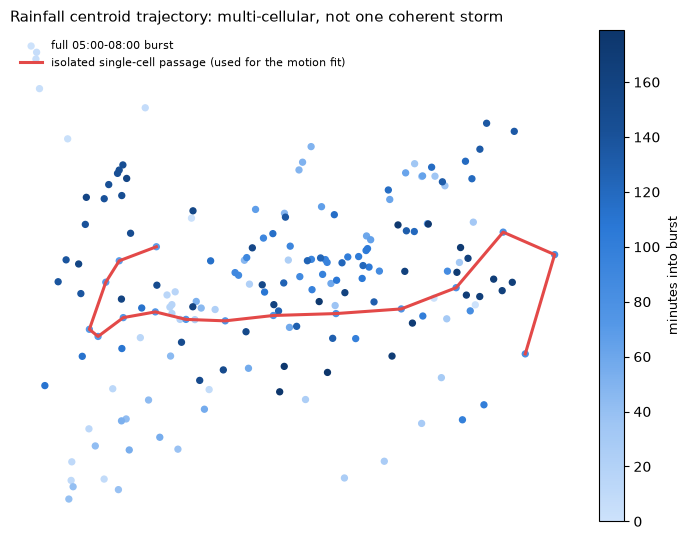

In [5]:
traj = adv.centroid_trajectory(cube)
burst = traj[(traj.time >= config.EVENT_BURST_START) & (traj.time < config.EVENT_BURST_END)]
fit_window = burst[(burst.time >= config.MOTION_FIT_START) & (burst.time < config.MOTION_FIT_END)]

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(burst.cx, burst.cy, c=(burst.time - burst.time.iloc[0]).dt.total_seconds() / 60,
                 cmap=figures.SEQUENTIAL_CMAP, s=18, label="full 05:00-08:00 burst")
ax.plot(fit_window.cx, fit_window.cy, color="#e34948", linewidth=2.2, zorder=5,
        label="isolated single-cell passage (used for the motion fit)")
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.03); cbar.set_label("minutes into burst", fontsize=9)
ax.set_title("Rainfall centroid trajectory: multi-cellular, not one coherent storm", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout()


speed=6.80 m/s (24.5 km/hr)  bearing=90.9° (due east)  R²(along-track)=0.87
footprint reconstruction R² across 58 pixels: median=0.24 (the storm's translation is well-determined; per-pixel detail is noisier since real cells grow and decay, not just translate)


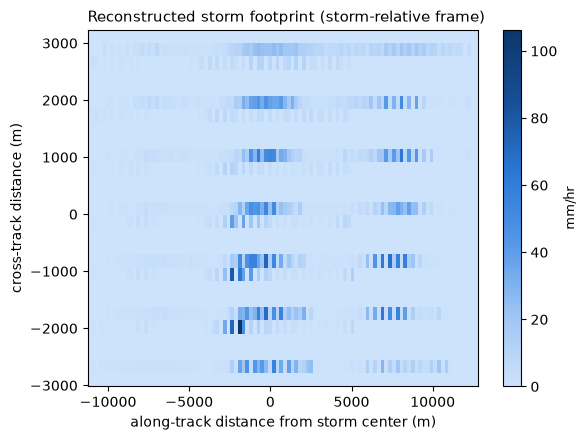

In [6]:
motion = adv.estimate_motion(cube)
print(f"speed={motion.speed_ms:.2f} m/s ({motion.speed_ms*3.6:.1f} km/hr)  bearing={motion.bearing_deg:.1f}° "
      f"(due east)  R²(along-track)={motion.r2_x:.2f}")

fp = adv.build_footprint(cube, motion)
val = adv.validate_footprint(cube, motion, fp)
print(f"footprint reconstruction R² across 58 pixels: median={val.r2.median():.2f} "
      f"(the storm's translation is well-determined; per-pixel detail is noisier since real cells "
      f"grow and decay, not just translate)")

fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.pcolormesh(fp.u_centers, fp.w_centers, fp.F, cmap=figures.SEQUENTIAL_CMAP, shading="auto")
ax.set_xlabel("along-track distance from storm center (m)"); ax.set_ylabel("cross-track distance (m)")
ax.set_title("Reconstructed storm footprint (storm-relative frame)", loc="left", fontsize=11)
cbar = fig.colorbar(im, ax=ax); cbar.set_label("mm/hr", fontsize=9)
fig.tight_layout()


In [7]:
pixels = radar.discover_pixels()
gage_xy = np.array([[p.x_center, p.y_center] for p in pixels])
gage_ids = [f"px{p.pixel_id}" for p in pixels]

catalogue, values = adv.build_realizations(cube, motion, fp, gage_xy, gage_ids)
display(catalogue[["realization_id", "direction_label", "domain_total_mm", "renorm_factor",
                    "peak_centroid_x", "peak_centroid_y", "event_centroid_x", "event_centroid_y"]]
        .round(2))

# every realization must deliver (post-renormalization) the same total rainfall as the baseline --
# this is the controlled variable that isolates "path" as the only thing that varies.
assert np.allclose(catalogue.domain_total_mm, catalogue.domain_total_mm.iloc[0], rtol=0.01), \
    "renormalization failed to equalize domain-total rainfall across realizations"
print("OK: all 9 realizations deliver the same domain-total rainfall (±1%).")


,realization_id,direction_label,domain_total_mm,renorm_factor,peak_centroid_x,peak_centroid_y,event_centroid_x,event_centroid_y
0,R00_baseline,observed,7.18,1.00,584015.58,6134331.24,583391.30,6134478.78
1,R01_S-N,S->N,7.18,6.88,584649.32,6133245.66,584170.80,6134317.63
2,R02_SW-NE,SW->NE,7.18,3.10,583792.60,6133694.52,583610.15,6134118.96
3,R03_W-E,W->E,7.18,0.94,581073.77,6134587.00,583020.45,6134515.01
4,R04_NW-SE,NW->SE,7.18,3.03,583351.07,6134560.30,583361.08,6134731.98
5,R05_N-S,N->S,7.18,1.56,583969.70,6133412.81,584037.56,6134369.98
6,R06_NE-SW,NE->SW,7.18,3.17,583639.31,6134664.63,583320.33,6134195.02
7,R07_E-W,E->W,7.18,1.80,583946.10,6134777.05,583093.65,6134578.67
8,R08_SE-NW,SE->NW,7.18,2.92,583965.44,6134932.00,583584.38,6134899.40


OK: all 9 realizations deliver the same domain-total rainfall (±1%).


## Part 4. Draping a surface over the pipes

Everything so far lives underground. Rain lands on a subcatchment, runs into a pipe, and if that pipe fills past
capacity the water has nowhere to go. Real flooding happens when water pushes up out of a manhole and spreads across
streets and gardens, so the model needs a ground surface for it to spread over.

That surface is a mesh, which is a sheet of triangles laid over the terrain with each triangle carrying its own
water depth. Picture chain mail draped across a landscape, fine enough to follow the shape of the ground and coarse
enough to compute. Elevation comes from the supplied SRTM data, resampled onto an exact 30 meter grid in the model's
own coordinate system, which gives roughly 23,000 triangles across the catchment.

Two pieces of software share this job and the division is worth understanding. The `mesh.py` module in this project
decides where triangles go, reading the elevation raster and emitting a list of corner points along with the
triangles that connect them. The engine's own `MeshBuilder` then turns that raw list into something a solver can
use. It works out which triangles share an edge, so water knows where it is allowed to flow. It identifies the outer
edges where water leaves the model. It computes each triangle's area, center and outward facing direction, and it
checks the whole assembly for degenerate geometry before anything runs. A pile of triangles only becomes a mesh once
that stitching has happened.

The final connection is the manholes. Each junction in the pipe network is tied to the triangle sitting above it,
which turns it into a two way door. Water surcharging from a full pipe arrives on the surface, and surface water
running over a manhole drains back down. For that exchange to mean anything, the ground elevation and the network's
own recorded manhole rim elevations have to agree about where the ground is, so we compare them and find a median
difference under a meter, which is close enough to trust.

One consequence of a 30 meter grid deserves attention when reading later results. A cell that size averages over
whole buildings and the streets between them, so this model cannot tell you that a particular road floods to the
curb. It can tell you that one district floods more than another under a given storm. Read the depths as a
comparison between trajectories rather than as survey data.


mesh: 23,320 triangles, 12,233 vertices, 1,146 boundary edges, 1011/1011 nodes coupled
DEM vs. network rim elevations: median offset -0.90 m


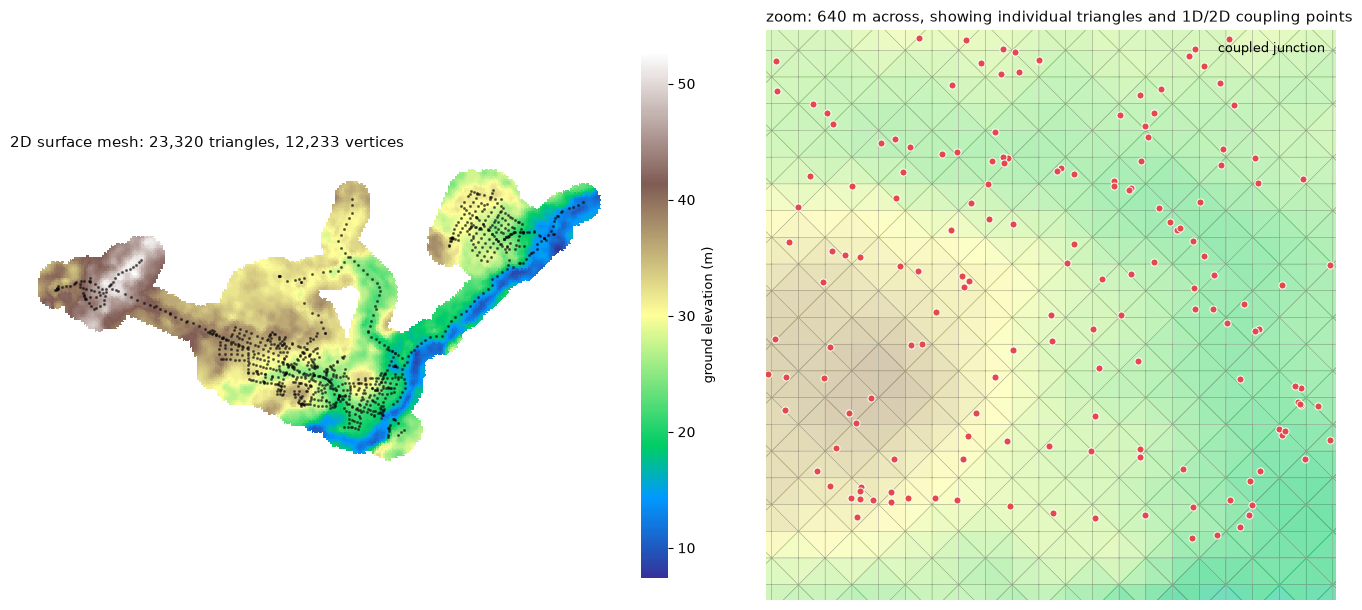

In [8]:
mesh = mesh_mod.build_mesh(nodes, poly_xy, force=FORCE_RERUN)
print(f"mesh: {len(mesh.triangles):,} triangles, {len(mesh.vertices):,} vertices, "
      f"{len(mesh.boundary_edges):,} boundary edges, {len(mesh.triangle_node_map)}/{len(nodes)} nodes coupled")
print(f"DEM vs. network rim elevations: median offset {mesh.dem_minus_rim_median_m:+.2f} m")

figures.mesh_figure(mesh, nodes)
plt.show()


In [9]:
base_sections = model.build_base_sections(inp_text, mesh, gage_xy, gage_ids)
print("base .inp assembled: 58 radar-pixel gages feed both 1D and 2D; ponding routed to the surface mesh")


base .inp assembled: 58 radar-pixel gages feed both 1D and 2D; ponding routed to the surface mesh


## Part 5. One test run before committing to nine

The full comparison takes several minutes, so it is worth confirming the model behaves before spending them.

The most useful check is continuity, which is really just accounting. All the water that entered the model has to
equal the water that left, plus whatever is still sitting inside it. An engine that quietly loses or invents water
will still produce confident looking flood maps, and continuity error is how you catch that before you believe them.
Anything under a few percent is healthy, and the numbers here come in far below that.

We also confirm the pipes and the surface are genuinely talking to each other by checking that water moved in both
directions through the manhole connections, and we time the run so we know what nine of them will cost.


### `openswmm.engine` bindings used below

This is the first cell that drives the engine directly. Everything above it (radar parsing, advection, mesh
building, `.inp` assembly) is pure-Python data prep — none of it touches `openswmm.engine`. Here we open a
`Solver`, step it to completion, and read results from three binding classes:

```python
from openswmm.engine import Solver, HAS_2D, Statistics, MassBalance

with Solver("model.inp") as s:          # PB — engine lifecycle; context manager loads & runs
    assert HAS_2D and s.surface2d.is_active   # PB — HAS_2D flag + Surface2D view
    surf = s.surface2d                        # PB — 2D surface handle
    for _ in s.steps():                       # PB — step iterator (yields timedelta per step)
        pass
    mb1d = MassBalance(s)                    # PB — 1D continuity queries
    stats = Statistics(s)                     # PB — cumulative node/link statistics
    mb2d = surf.get_mass_balance()           # PB — 2D mass-balance dict

    # PB properties — live queries against the engine handle:
    mb1d.runoff_continuity_error             # PB — float (%)
    mb1d.routing_continuity_error            # PB — float (%)
    mb2d["continuity_error"]                # PB — float
    mb2d["rainfall_in"]                      # PB — m³
    mb2d["coupling_1d_to_2d_in"]            # PB — m³ (pipe surcharge → surface)
    mb2d["coupling_2d_to_1d_out"]           # PB — m³ (surface draining back)
    mb2d["boundary_out"]                     # PB — m³
    stats.node_vol_flooded                   # PB — NDArray (m³ per node)
```

`model.write_realization_inp` (the first line of the cell) is **not** from the bindings — it's `swmm_storm.model`
writing a `.inp` text file to disk. The bindings only enter at `Solver(...)`.

In [10]:
from openswmm.engine import Solver, HAS_2D, Statistics, MassBalance
import time

baseline_path = model.write_realization_inp(base_sections, "R00_baseline", gage_ids,
                                             values["R00_baseline"].index, values["R00_baseline"].values)

t0 = time.time()
with Solver(str(baseline_path)) as s:
    assert HAS_2D and s.surface2d.is_active, "2D module did not activate"
    surf = s.surface2d
    for _ in s.steps():
        pass
    wall_s = time.time() - t0
    mb1d, stats, mb2d = MassBalance(s), Statistics(s), surf.get_mass_balance()

    # MassBalance/Statistics properties are LIVE queries against the engine
    # handle, not cached snapshots -- capture plain floats before `with`
    # exits and destroys the handle (a BadHandleError follows any read
    # attempted after that point).
    runoff_err = mb1d.runoff_continuity_error
    routing_err = mb1d.routing_continuity_error
    continuity_2d = mb2d["continuity_error"]
    node_flooded_total = float(stats.node_vol_flooded.sum())
    n_flooded = int((stats.node_vol_flooded > 0).sum())

    print(f"wall clock: {wall_s:.1f} s for the full 6-hour simulation")
    print(f"1D runoff continuity error:  {runoff_err:.4f} %")
    print(f"1D routing continuity error: {routing_err:.4f} %")
    print(f"2D continuity error:         {continuity_2d:.2e}")
    print(f"2D rainfall in:              {mb2d['rainfall_in']:.0f} m^3")
    print(f"2D coupling 1D->2D (surcharge to surface): {mb2d['coupling_1d_to_2d_in']:.0f} m^3")
    print(f"2D coupling 2D->1D (surface draining back): {mb2d['coupling_2d_to_1d_out']:.0f} m^3")
    print(f"2D boundary outflow:         {mb2d['boundary_out']:.0f} m^3")
    print(f"1D node flooded volume (sum): {node_flooded_total:.0f} m^3 across {n_flooded} nodes")

assert abs(runoff_err) < 5 and abs(routing_err) < 5, "1D continuity gate failed"
assert abs(continuity_2d) < 0.05, "2D continuity gate failed"
print("\nAll smoke-test gates passed.")
print(f"Projected ensemble time at {config.N_WORKERS} workers: "
      f"~{9 / config.N_WORKERS * wall_s:.0f} s")


OMP: Info #109: kmp_set_blocktime(ms) maximum value "-1162174820" will be used.


wall clock: 38.8 s for the full 6-hour simulation
1D runoff continuity error:  -0.0007 %
1D routing continuity error: 0.0316 %
2D continuity error:         1.41e-15
2D rainfall in:              81889 m^3
2D coupling 1D->2D (surcharge to surface): 577 m^3
2D coupling 2D->1D (surface draining back): 10278 m^3
2D boundary outflow:         10088 m^3
1D node flooded volume (sum): 53909 m^3 across 156 nodes

All smoke-test gates passed.
Projected ensemble time at 1 workers: ~349 s


## Part 6. Running all nine storms

Each of the nine trajectories now gets a full simulation. Results are cached, so re-running this notebook reuses
completed work unless you set `FORCE_RERUN` to True.

One practical note on how these are run. The obvious way to speed this up is to launch several simulations as
separate operating system processes at once. On this machine that crashed reliably, taking down a couple of workers
partway through and leaving the rest waiting forever on results that were never coming. The cause sits in a shared
native library during startup rather than in the model, and a single simulation on its own never has trouble.
Rather than fight it, this notebook runs the nine one after another. Part 7 gets its concurrency a different way, by
holding several engines inside a single process, which avoids the problem entirely.


### `openswmm.engine` bindings used inside `run.run_ensemble`

This cell calls `run.run_ensemble(...)`, which looks like an ordinary `swmm_storm` function — but internally it
drives the engine for every realization. Each run goes through the same `Solver` → `steps()` → `MassBalance` /
`Statistics` / `Surface2D` lifecycle shown in Part 5, then extracts per-node and per-triangle arrays. Here is
the binding call site inside `swmm_storm/run.py`:

```python
from openswmm.engine import Solver, HAS_2D, Statistics, MassBalance

with Solver(str(inp_path)) as s:              # PB — open one realization
    surf = s.surface2d                        # PB — 2D surface handle
    for _ in s.steps():                       # PB — advance to completion
        pass
    mb1d = MassBalance(s)                     # PB
    stats = Statistics(s)                     # PB
    mb2d = surf.get_mass_balance()            # PB

    # PB — read results for the metrics table:
    mb1d.runoff_continuity_error              # PB — float (%)
    mb1d.routing_continuity_error             # PB — float (%)
    mb2d["continuity_error"]                  # PB — float
    mb2d["rainfall_in"]                       # PB — m³
    mb2d["coupling_1d_to_2d_in"]             # PB — m³
    mb2d["coupling_2d_to_1d_out"]            # PB — m³
    mb2d["boundary_out"]                      # PB — m³
    stats.node_vol_flooded                    # PB — NDArray (m³ per node)
    stats.node_max_depth                      # PB — NDArray (m per node)
    stats.node_time_flooded                   # PB — NDArray (hr per node)
    stats.node_max_overflow                   # PB — NDArray (m³/s per node)
    s.nodes.get_id(i)                         # PB — node name by index
    surf.get_stat_max_depths()                # PB — NDArray (m per triangle)
    surf.get_stat_max_velocities()            # PB — NDArray (m/s per triangle)
    surf.get_triangle_area(i)                 # PB — float (m²)
    surf.n_triangles                          # PB — int
```

The cell itself only calls `run.run_ensemble` and works with the returned pandas `DataFrame` — the binding usage
is hidden one layer down in `swmm_storm.run`.

In [11]:
t0 = time.time()
metrics = run.run_ensemble(base_sections, catalogue, values, n_workers=config.N_WORKERS, force=FORCE_RERUN)
print(f"ensemble wall time: {time.time() - t0:.1f} s")

cols = ["realization_id", "direction_label", "wall_s", "runoff_continuity_error_pct",
        "routing_continuity_error_pct", "continuity_error_2d", "flood_volume_2d_m3",
        "max_depth_2d_m", "node_vol_flooded_total_m3", "n_nodes_flooded"]
display(metrics[cols].round(3))

flagged = metrics[(metrics.runoff_continuity_error_pct.abs() > 5)
                   | (metrics.routing_continuity_error_pct.abs() > 5)
                   | (metrics.continuity_error_2d.abs() > 0.05)]
if len(flagged):
    print("\nWARNING -- continuity outside gate thresholds for:", flagged.realization_id.tolist())
else:
    print("\nAll 9 runs within continuity gate thresholds.")


ensemble wall time: 0.4 s


,realization_id,direction_label,wall_s,runoff_continuity_error_pct,routing_continuity_error_pct,continuity_error_2d,flood_volume_2d_m3,max_depth_2d_m,node_vol_flooded_total_m3,n_nodes_flooded
0,R00_baseline,observed,50.827,-0.001,0.032,0.0,46609.490,0.604,53908.515,156
1,R01_S-N,S->N,45.755,-0.002,0.028,-0.0,73463.008,0.821,246211.182,370
2,R02_SW-NE,SW->NE,55.539,-0.001,0.030,0.0,48477.017,0.608,112306.704,300
3,R03_W-E,W->E,40.712,-0.001,0.031,-0.0,43826.367,0.577,49008.206,126
4,R04_NW-SE,NW->SE,39.975,-0.001,0.023,-0.0,52460.333,0.897,162143.264,324
5,R05_N-S,N->S,38.951,-0.001,0.032,-0.0,56744.290,0.670,92029.743,265
6,R06_NE-SW,NE->SW,38.144,-0.001,0.050,-0.0,47938.955,0.847,90755.087,162
7,R07_E-W,E->W,35.521,-0.001,0.030,-0.0,39364.172,0.550,39815.818,154
8,R08_SE-NW,SE->NW,32.632,-0.001,0.013,0.0,44958.684,0.770,71608.557,222



All 9 runs within continuity gate thresholds.


## Part 7. Six storms, six engines, one process

Everything up to this point has been sequential. Open a simulation, run it to the end, close it, start the next one.
That is the ordinary way to work, and it means the only way to compare two storms is to finish both and inspect the
wreckage afterward.

Here we do something different. Six trajectories are opened at once, each with its own `Solver`, and all six are
held open together in this notebook's memory. Then we walk down the row of them exactly like the grandmaster at the
simultaneous exhibition, advancing each one by fifteen simulated minutes before moving on to the next, twenty four
times over. Every panel in the animation below is therefore showing the same moment of the same storm event playing
out six different ways.

The six were chosen to span the range of outcomes, from the trajectory that floods the catchment least to the one
that floods it most, with the observed storm included as a reference. Each panel shows water spreading across the
2D surface, and each title counts how many manholes have flooded so far, so you can watch the underground network
and the street surface fill together.

Watching them side by side reveals something the summary statistics cannot. These storms are not milder and worse
versions of one another. They put water in different places, and they put it there at different times, and timing
governs whether a pipe has drained enough to accept the next surge or is still full when it arrives.

A note on the shape of the experiment. All nine trajectories are built to pass through the same point at the same
moment, the observed storm's peak. They approach from six directions, converge on that instant, and separate again
afterward. Any apparent agreement in the middle of the animation is therefore built into the design and should not
be read as a result.

If you are reading this on GitHub rather than in a running Jupyter session, the interactive animation below will
appear blank, because GitHub strips the JavaScript that drives it. The same animation is saved as a GIF, which does
display:

![Six trajectories advancing together](media/trajectory_animation.gif)

This section also cost a bug worth recording. Opening a second `Solver` while the first was still open crashed the
process immediately, but only when the mapping library used elsewhere in this notebook had been loaded first.
Running one simulation at a time was never affected, which is why nothing earlier in the notebook noticed. The fix
is an import ordering rule in the setup cell, and `run.run_live_multi_engine` now checks for the bad order and
raises a clear error rather than dying silently.


In [12]:
# Six bearings spanning the outcome range, chosen from the already-computed
# 25-bearing sweep's results (cache/sweep_run.log): the calmest (270 deg),
# a low case (090), a mid-high case (060), a high case (000), and the most
# severe (165), alongside the observed baseline.
live_bearings = {b: l for b, l in adv.compass_bearings(24).items() if b in {0.0, 60.0, 90.0, 165.0, 270.0}}
catalogue_live, values_live = adv.build_realizations(
    cube, motion, fp, gage_xy, gage_ids, bearings=live_bearings, id_prefix="L")

live_ids = catalogue_live.realization_id.tolist()
for rid in live_ids:
    row = values_live[rid]
    model.write_realization_inp(base_sections, rid, gage_ids, row.index, row.values)
print(f"{len(live_ids)} trajectories staged for the live multi-engine run: {live_ids}")


6 trajectories staged for the live multi-engine run: ['L00_baseline', 'L01_000', 'L02_060', 'L03_090', 'L04_165', 'L05_270']


### `openswmm.engine` bindings used inside `run.run_live_multi_engine`

This is the reentrant-engine payoff. `run.run_live_multi_engine` opens **six** `Solver` objects at once in a
single Python process, holds them all open simultaneously, and interleave-steps them to shared elapsed-time
checkpoints — capturing a live snapshot from every engine at each one. The staging cell above only builds
`.inp` files (no bindings); the binding usage is all inside `run.run_live_multi_engine` in `swmm_storm/run.py`:

```python
from openswmm.engine import Solver, HAS_2D, Statistics

with ExitStack() as stack:
    # PB — open N solvers at once; each is an independent, reentrant handle:
    solvers = {rid: stack.enter_context(Solver(str(p)))
               for rid, p in paths.items()}

    for s in solvers.values():
        assert HAS_2D and s.surface2d.is_active     # PB — verify 2D on each

    # PB — read node names from the first solver:
    s0 = solvers[realization_ids[0]]
    node_names = [s0.nodes.get_id(i)
                 for i in range(len(Statistics(s0).node_vol_flooded))]

    for target in checkpoints:                      # 15-min steps across 6h
        for rid, s in solvers.items():
            s.until(target)                         # PB — advance to elapsed time
            surf = s.surface2d                      # PB — 2D surface handle
            stats = Statistics(s)                   # PB — statistics for this moment
            frame[rid] = {
                "tri_depths": surf.get_depths().copy(),       # PB — NDArray (m per triangle, live)
                "node_vol_flooded": stats.node_vol_flooded.copy(),  # PB — NDArray (m³ per node, live)
            }
```

The key binding features this exercises:

- **`Solver` is reentrant** — N independent handles coexist in one process with no shared global state.
- **`s.until(target)`** — advances one solver to a specific elapsed `timedelta`, not to completion.
- **`surf.get_depths()`** — live per-triangle water depths at the current simulation instant (not a
  post-run statistic like `surf.get_stat_max_depths()` used in Part 6).
- **`stats.node_vol_flooded`** — live flooded volume per node at the current instant.

The notebook cell itself only calls `run.run_live_multi_engine(live_ids)` and receives `(node_names, frames)`;
all the binding usage is one layer down.

In [13]:
live_labels = {row.realization_id: ("observed (baseline)" if pd.isna(row.bearing_deg)
                                    else f"{row.bearing_deg:03.0f}°")
              for _, row in catalogue_live.iterrows()}

t0 = time.time()
node_names_live, live_frames = run.run_live_multi_engine(live_ids)
print(f"{len(live_ids)} engines held open simultaneously, "
      f"{len(live_frames)} shared checkpoints, {time.time() - t0:.0f}s wall time")


OMP: Info #109: kmp_set_blocktime(ms) maximum value "-1162174676" will be used.
OMP: Info #109: kmp_set_blocktime(ms) maximum value "-1162174676" will be used.
OMP: Info #109: kmp_set_blocktime(ms) maximum value "-1162174676" will be used.
OMP: Info #109: kmp_set_blocktime(ms) maximum value "-1162174676" will be used.
OMP: Info #109: kmp_set_blocktime(ms) maximum value "-1162174676" will be used.
OMP: Info #109: kmp_set_blocktime(ms) maximum value "-1162174676" will be used.


6 engines held open simultaneously, 24 shared checkpoints, 261s wall time


In [14]:
from IPython.display import HTML

live_anim = figures.live_multi_engine_grid_animation(node_names_live, live_frames, mesh, live_labels)
HTML(live_anim.to_jshtml())


## Part 8. Comparing the nine outcomes

The animation showed character. These plots show magnitude.

Each box summarizes how flooding is distributed across space within a single trajectory, gathering every manhole
that flooded or every wet triangle on the surface, with a diamond marking the catchment wide total. Reading across
the boxes tells you whether a given storm direction produces a handful of severe local failures or widespread
shallow nuisance flooding, which are very different problems for whoever has to manage them and call for different
interventions.

The spread between the mildest and worst trajectory is the number to carry away. Every one of these is the same
storm delivering the same water. If a design standard specifies only a depth and a duration with no direction
attached, the resulting estimate of flood volume can land anywhere inside that range depending on a factor the
design never considered.


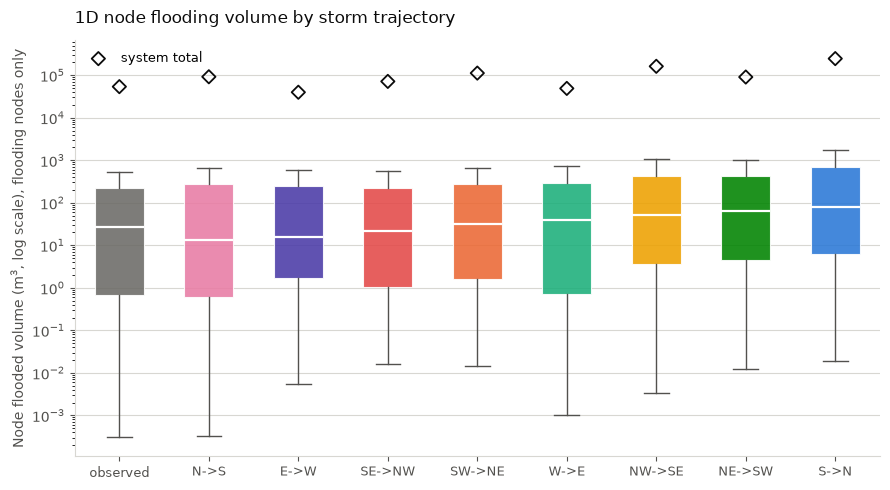

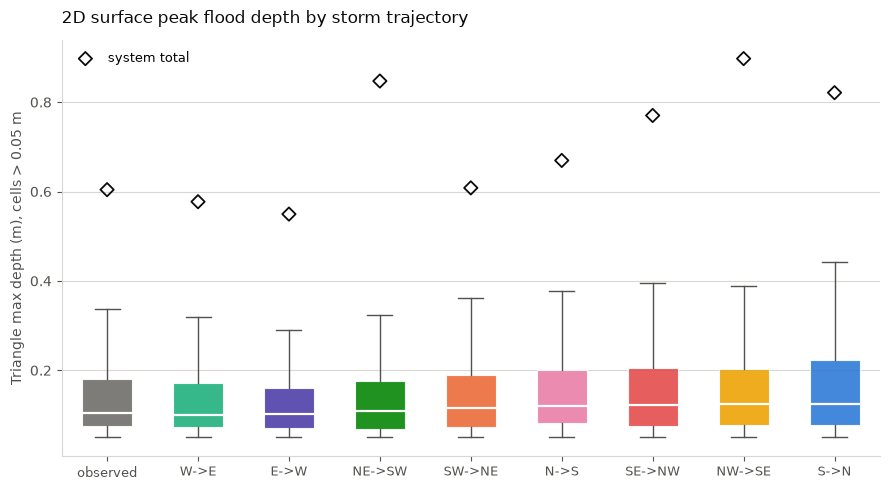

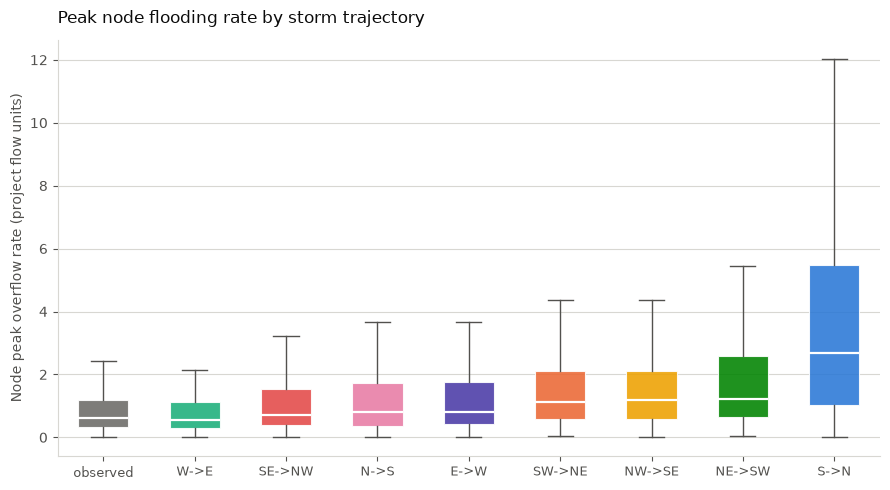

In [15]:
fig1 = figures.flood_volume_boxplot(metrics, catalogue)
fig2 = figures.max_depth_boxplot(metrics, catalogue)
fig3 = figures.peak_flooding_rate_boxplot(metrics, catalogue)
plt.show()


## What to take from this

Every storm in this notebook carried the same water. The rainfall totals were normalized to within one percent of
each other precisely so that nothing else could account for the results. Whatever difference appears in the flood
volumes came from the direction the storm traveled.

That carries a direct implication for practice. A design storm has no direction, so it cannot express this effect at
all, and a drainage system signed off against one may be considerably more exposed to some storm tracks than the
design run implies. Where that exposure sits depends on how the storm's path interacts with the network's own
drainage direction, which is the kind of thing that has to be simulated rather than reasoned about from a map.

A few limits are worth carrying forward. The terrain is represented at 30 meters with no buildings, so these depths
compare trajectories against each other and should not be read as street level predictions. The frozen field
reconstruction captures the storm's movement well and its internal evolution poorly, quantified by the R squared
values in Part 3. And this is one storm over one catchment, so the size of the effect found here does not transfer
to another site, although the existence of the effect is worth checking wherever you work.
